# YZM2022 Data Mining - Homework 2 : Text Mining & Classification

**Tuğana Öykü Yıldız - 24018020**



## 1. Objective

Recent advances in artificial intelligence have enabled systems to generate highly realistic human-like text. This creates a critical need to distinguish between machine-generated and human-written content.

The main objective of this assignment is to develop machine learning models that can
classify whether a given text is generated by an AI system or written by a human.

### LIBRARIES & ENVIRONMENT SETUP

In [1]:
# Temel kütüphaneler
import os
import re
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import gc
import shutil
import nltk

# Warnings gizle ve reproducibility için seed belirle
warnings.filterwarnings("ignore")
np.random.seed(42)

# NLP
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.tokenize import word_tokenize

# Gerekli NLTK verilerini indir (ilk çalıştırmada gerekli)
for pkg in ["punkt", "punkt_tab", "stopwords", "wordnet", "omw-1.4"]:
    try:
        nltk.download(pkg, quiet=True)
    except Exception as e:
        print(f"NLTK {pkg} indirilemedi: {e}")

# sklearn - feature extraction
from sklearn.feature_extraction.text import TfidfVectorizer

# sklearn - classifiers
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# sklearn - feature selection
from sklearn.feature_selection import SelectKBest, chi2, mutual_info_classif, f_classif
from skrebate import ReliefF

# sklearn - model selection & metrics
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_curve, auc, confusion_matrix, classification_report)
from sklearn.preprocessing import LabelEncoder

# Visualization
from collections import Counter
try:
    from wordcloud import WordCloud
    WC_AVAILABLE = True
except ImportError:
    WC_AVAILABLE = False
    print("WordCloud library is not installed. Word cloud generation will be skipped.")

print("All libraries loaded successfully!")

All libraries loaded successfully!


## 2. Dataset

Our dataset consists of exactly **10,000 texts**: 5,000 human-written (`human`) and 5,000 machine-generated (`machine`). Since the target classes are perfectly balanced, there is no need to apply resampling techniques such as Synthetic Minority Over-sampling Technique.

**Columns:**
- `text`: The raw text content.
- `label_cat`: The target classification label (`human` or `machine`).


In [2]:
# Veriyi yükle
DATA_PATH = "human_machine_dataset.csv"
df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
print("Kolonlar:", df.columns.tolist())
print("\nSınıf dağılımı:")
print(df["label_cat"].value_counts())
print("\nEksik değerler:")
print(df.isna().sum())

df.head(3)

Shape: (10000, 2)
Kolonlar: ['text', 'label_cat']

Sınıf dağılımı:
label_cat
human      5000
machine    5000
Name: count, dtype: int64

Eksik değerler:
text         0
label_cat    0
dtype: int64


,text,label_cat
0,All the Love you do not see\n\nOn writing with...,human
1,"Reading, writing and displaying images\n\nBefo...",human
2,Why I Think “Target Audience” Doesn’t Always M...,human


### Text Examples

Let's look at one human text and one machine text. Machine texts can sometimes look strange or repeat things. Human texts usually look more natural.


In [3]:
print("---- HUMAN örnek ----")
print(df[df["label_cat"] == "human"].iloc[0]["text"][:500])

print("\n---- MACHINE örnek ----")
print(df[df["label_cat"] == "machine"].iloc[0]["text"][:500])


---- HUMAN örnek ----
All the Love you do not see

On writing with heart and hope

Photo by JOSHUA COLEMAN on Unsplash

The words I do not recognize are the ones my heart wrote, so feverish with hope every line feels like a hallucination.

And yet, these moments happened and still happen, everything is true. Suddenly, life is poetry and joy opens up portal into new universes that leave you speechless. Unless you surrender to it, you cannot experience awe; that surrender is not verbal. Transcription takes place well a

---- MACHINE örnek ----
[it's] difficult to get beyond the overall blandness of american chai , despite its likable performances and refreshingly naive point of view . Still a great example of a better idea ). I thought I had more and more to do this last week, but we didn't have all the answers in the text (which, I really believe was due to a misunderstanding of the main plot, I missed each of the parts).

I'm afraid that the ending is an insult, but that's a good start

### Text Length (Histograms)

Let's check the length of the texts. We will make graphs for word count and character count. This helps our models find clues. For example, maybe machines write longer texts.


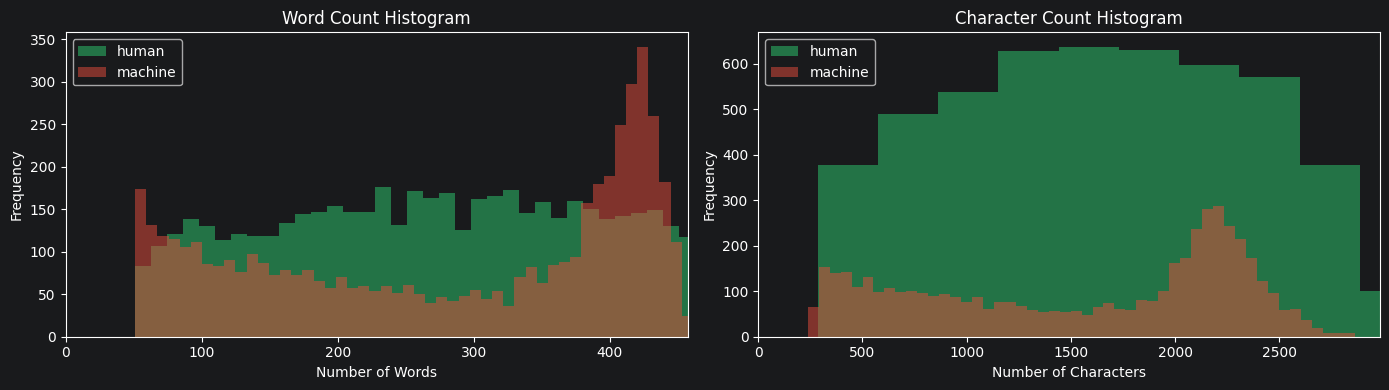

In [4]:
# Metin uzunluklarını hesapla
df["char_len"] = df["text"].astype(str).apply(len)
df["word_len"] = df["text"].astype(str).apply(lambda x: len(x.split()))

# Yan yana iki subplot oluştur
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Word Count histogramı
for lab, color in zip(["human", "machine"], ["#2ecc71", "#e74c3c"]):
    subset = df[df["label_cat"] == lab]["word_len"]
    axes[0].hist(subset, bins=50, alpha=0.5, label=lab, color=color)

axes[0].set_title("Word Count Histogram")
axes[0].set_xlabel("Number of Words")
axes[0].set_ylabel("Frequency")
axes[0].legend()
# Outlierları grafikten gizlemek için x eksenini 99. yüzdelik dilimle sınırla
axes[0].set_xlim(0, np.percentile(df["word_len"], 99))

# Character Count histogramı
for lab, color in zip(["human", "machine"], ["#2ecc71", "#e74c3c"]):
    subset = df[df["label_cat"] == lab]["char_len"]
    axes[1].hist(subset, bins=50, alpha=0.5, label=lab, color=color)

axes[1].set_title("Character Count Histogram")
axes[1].set_xlabel("Number of Characters")
axes[1].set_ylabel("Frequency")
axes[1].legend()
# Outlierları grafikten gizlemek için x eksenini 99. yüzdelik dilimle sınırla
axes[1].set_xlim(0, np.percentile(df["char_len"], 99))

plt.tight_layout()

# Grafiği  kaydet
plt.savefig("outputs/fig_length_histograms.png", dpi=120, bbox_inches="tight")
plt.show()

In [5]:
# İstatistiksel özet tablosunu yazdır
print("\nDescriptive Statistics for Text Lengths:")
print(df.groupby("label_cat")[["char_len", "word_len"]].describe().round(1))


Descriptive Statistics for Text Lengths:
          char_len                                                         \
             count    mean    std    min     25%     50%     75%      max   
label_cat                                                                   
human       5000.0  1663.2  783.4  285.0  1072.5  1657.5  2231.0  14733.0   
machine     5000.0  1545.4  740.3  238.0   819.0  1772.5  2198.0   2864.0   

          word_len                                                  
             count   mean    std   min    25%    50%    75%    max  
label_cat                                                           
human       5000.0  267.4  115.3  51.0  174.0  270.0  365.0  639.0  
machine     5000.0  281.8  135.8  51.0  147.0  323.0  410.0  461.0  


## 3. Methodology


### 3.1 Text Preprocessing

Now we clean the text data. We do these four steps:
1. Lowercasing: Make all letters small.
2. Tokenization: Split sentences into words.
3. Stopword Removal: Delete very common words (like "the", "a", "is").
4. Lemmatization: Find the base form of the word (e.g., "running" → "run").

*Note: We use Lemmatization instead of Stemming. Stemming can break words, Lemmatization finds the correct dictionary word. We also remove numbers and punctuation.*


In [6]:
# objeleri her satır için baştan yaratmamak adına dışarıda tanımlıyoruz
STOPWORDS = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def preprocess(text: str) -> str:
    if not isinstance(text, str):
        return ""

    # lowercasing
    text = text.lower()

    # harf dışındaki her şeyi boşlukla değiştir
    text = re.sub(r"[^a-z\s]", " ", text)

    # tokenization
    tokens = word_tokenize(text)

    # stopwords filtrelemesi, kısa kelimeleri atma ve lemmatization
    cleaned = [
        lemmatizer.lemmatize(tok)
        for tok in tokens
        if tok not in STOPWORDS and len(tok) > 2
    ]

    return " ".join(cleaned)


# ufak bir test
demo = "The quick brown foxes are running faster than the lazy dogs! 123"
print("Original:", demo)
print("Cleaned: ", preprocess(demo))

# tüm veri setine uygulama
print("\nCleaning the text dataset...")
start_time = time.time()

df["cleaned_text"] = df["text"].apply(preprocess)

print(f"Finished in {round(time.time() - start_time, 2)} seconds.")
df[["text", "cleaned_text"]].head(3)

Original: The quick brown foxes are running faster than the lazy dogs! 123
Cleaned:  quick brown fox running faster lazy dog

Cleaning the text dataset...
Finished in 9.47 seconds.


,text,cleaned_text
0,All the Love you do not see\n\nOn writing with...,love see writing heart hope photo joshua colem...
1,"Reading, writing and displaying images\n\nBefo...",reading writing displaying image anything comp...
2,Why I Think “Target Audience” Doesn’t Always M...,think target audience always matter much first...


### Apply Preprocessing

We apply the cleaning function to all texts. Sometimes, cleaning deletes everything in a text. We will drop these empty or very short texts to help our models.


In [7]:
# tüm veri setine temizleme işlemini uygula
t0 = time.time()
df["clean_text"] = df["text"].astype(str).apply(preprocess)
print(f"Preprocessing tamamlandı ({time.time()-t0:.1f} sn)")

# temizlik sonrası çok kısa veya boş kalan metinleri veri setinden çıkarıyoruz
before = len(df)
df = df[df["clean_text"].str.split().str.len() > 2].reset_index(drop=True)
print(f"Çok kısa/boş metinler atıldı: {before} -> {len(df)}")

df[["text", "clean_text", "label_cat"]].head(3)


Preprocessing tamamlandı (8.5 sn)
Çok kısa/boş metinler atıldı: 10000 -> 9991


,text,clean_text,label_cat
0,All the Love you do not see\n\nOn writing with...,love see writing heart hope photo joshua colem...,human
1,"Reading, writing and displaying images\n\nBefo...",reading writing displaying image anything comp...,human
2,Why I Think “Target Audience” Doesn’t Always M...,think target audience always matter much first...,human


### Label Encoding

Machine learning models need numbers, not words. We change our text labels into numbers. For example, human becomes 0 and machine becomes 1.


In [8]:
le = LabelEncoder()
y = le.fit_transform(df["label_cat"])
print("Sınıflar:", list(le.classes_))
print("Etiket dağılımı:", np.bincount(y))

# modelin kullanacağı girdi (X) ve çıktı (y) değişkenlerini ayırıyoruz
X_text = df["clean_text"].values

Sınıflar: ['human', 'machine']
Etiket dağılımı: [5000 4991]


### 3.2 Feature Extraction - TF-IDF (Unigram + Bigram)

We need to extract features using Unigram and Bigram combinations. Four different feature sizes: 500, 2000, 5000, and 10000.

We define the rules for TF-IDF. We also do a quick preview to see the matrix sizes. We delete the preview data immediately to prevent data leakage before cross validation.

We use TF-IDF to convert text into numbers. We set these rules:
* `ngram_range=(1,2)`: Use single words and two-word combinations.
* `max_features=K`: Keep only the top K most frequent features.
* `min_df=2`: Drop very rare words to clean the noise.

We will create a different TF-IDF setup for each feature size (500, 2000, 5000, 10000).

In [9]:
FEATURE_SIZES = [500, 2000, 5000, 10000]

def make_tfidf_params(k):
    return dict(
        ngram_range=(1, 2),  # unigram ve bigram
        max_features=k,      # en yüksek frekanslı k özellik
        min_df=2,
        max_df=0.95,         # dökümanların %95'inden fazlasında geçenleri at
        sublinear_tf=True    # logaritmik frekans ölçeklendirmesi (outliers)
    )

# matris boyutlarını görmek için geçici önizleme
for k in FEATURE_SIZES:
    vec_preview = TfidfVectorizer(**make_tfidf_params(k))
    X_preview = vec_preview.fit_transform(X_text)
    print(f"K={k:>5} -> shape (preview): {X_preview.shape}, nnz: {X_preview.nnz}")

# geçici değişkenleri siliyoruz
del vec_preview, X_preview

K=  500 -> shape (preview): (9991, 500), nnz: 372586
K= 2000 -> shape (preview): (9991, 2000), nnz: 633646
K= 5000 -> shape (preview): (9991, 5000), nnz: 783618
K=10000 -> shape (preview): (9991, 10000), nnz: 884862


### 3.3 Classification Algorithms

| Algorithm         | Parameters     | Reason                |
|-------------------|----------------|-----------------------|
| **KNN**           | k=5, cosine metric | Cosine distance works very well for text data.
| **Naive Bayes**   | MultinomialNB  | It is fast and standard for text classification. |
| **Decision Tree** | max_depth=20   | We limit the depth to stop overfitting. |
| **Random Forest** | 100 trees, max_depth=30 | It is a strong model and usually gives the best results. |

All models can calculate probabilities (predict_proba). We will need this later to draw ROC curves.

In [10]:
def make_classifiers():
    # Her çağrıldığında sıfırlanmış modeller döndürür.
    # Bu sayede cross-validation sırasında modeller eski bilgi taşımaz.
    return {
        "KNN":           KNeighborsClassifier(n_neighbors=5, metric="cosine", n_jobs=-1),
        "NaiveBayes":    MultinomialNB(),
        "DecisionTree":  DecisionTreeClassifier(max_depth=20, random_state=42),
        "RandomForest":  RandomForestClassifier(n_estimators=100, max_depth=30,
                                                n_jobs=-1, random_state=42),
    }

# test çağrısı
for name, clf in make_classifiers().items():
    print(f"{name:14s} -> {clf.__class__.__name__}")


KNN            -> KNeighborsClassifier
NaiveBayes     -> MultinomialNB
DecisionTree   -> DecisionTreeClassifier
RandomForest   -> RandomForestClassifier


### 3.4 Feature Selection

1. **ReliefF:** Finds features by looking at nearest neighbors. We use the `skrebate` library.
2. **Chi-Square (χ²):** Works fast and well with positive text data like TF-IDF.
3. **Information Gain (Mutual Information):** Measures how much a word tells us about the class.
4. **ANOVA F-test:** Looks at the variance between the two classes.
5. **All Features (Baseline):** No selection. We use this to see if our selection methods actually help.

**Warning for ReliefF:** ReliefF is very slow O(m·n·k) and does not support sparse matrices. Running it directly on 10,000 texts can crash the system. To fix this, we will train ReliefF on a small random subset (1,500 texts) to find the best features. Then, we will apply these selected features to the full dataset.

In [11]:
class ReliefFSelector:

    # ReliefF tabanlı özel özellik seçici.
    # Hız için subsample kullanır ve RAM tasarrufu sağlar.
    # Scikit-learn pipeline yapısına uyumludur.

    def __init__(self, k, sample_size=1500, n_neighbors=10, seed=42):
        self.k = k
        self.sample_size = sample_size
        self.n_neighbors = n_neighbors
        self.seed = seed
        self.selected_idx_ = None

    def fit(self, X, y):
        n = X.shape[0]
        rng = np.random.RandomState(self.seed)

        # veriyi alt kümeye böl
        if n > self.sample_size:
            idx = rng.choice(n, self.sample_size, replace=False)
            X_sub, y_sub = X[idx], y[idx]
        else:
            X_sub, y_sub = X, y

        # skrebate dense matrix istiyor, veri küçük olduğu için burada çevirmek güvenli
        X_sub_dense = X_sub.toarray() if hasattr(X_sub, "toarray") else np.asarray(X_sub)
        k_eff = min(self.k, X_sub_dense.shape[1])

        from skrebate import ReliefF
        rf = ReliefF(n_features_to_select=k_eff, n_neighbors=self.n_neighbors, n_jobs=-1)
        rf.fit(X_sub_dense, y_sub)

        # en iyi özelliklerin indekslerini kaydet
        self.selected_idx_ = np.array(rf.top_features_[:k_eff])
        return self

    def transform(self, X):
        # RAM tasarrufu için büyük veriyi dense matrise çevirmeden indeksle
        if hasattr(X, "tocsc"):
            return X.tocsc()[:, self.selected_idx_]
        return X[:, self.selected_idx_]

    def fit_transform(self, X, y):
        return self.fit(X, y).transform(X)


# tüm seçim yöntemlerini bir fabrikada topluyoruz
# lambda kullanımı sayesinde objeler sadece çağrıldığında (k değeri ile) yaratılacak
FS_FACTORIES = {
    "AllFeatures": None,
    "Chi2":        lambda k: SelectKBest(chi2, k=k),
    "InfoGain":    lambda k: SelectKBest(mutual_info_classif, k=k),
    "ANOVA-F":     lambda k: SelectKBest(f_classif, k=k),
    "ReliefF":     lambda k: ReliefFSelector(k=k, sample_size=1500, n_neighbors=10),
}

print("Feature selection options ready:", list(FS_FACTORIES.keys()))

Feature selection options ready: ['AllFeatures', 'Chi2', 'InfoGain', 'ANOVA-F', 'ReliefF']


## 4. Evaluation

### 4.1 Cross Validation

We use 5-fold Stratified Cross Validation. This means we split the data into 5 parts. We train the model on 4 parts and test it on 1 part. "Stratified" makes sure the number of human and machine texts stays balanced in every part.


### 4.2 Performance Metrics
We calculate these metrics for each part and find the average:
* **Accuracy:** How many texts did we guess correctly?
* **Precision:** When the model says "machine," how often is it right?
* **Recall:** Out of all real machine texts, how many did the model find?
* **F1-score:** The balance between Precision and Recall.
* **AUC (ROC):** A score that shows how well the model separates the two classes.

We also save all the predictions to draw ROC curves later.


In [12]:
def evaluate_model(X_text, y, tfidf_params, classifier_factory,
                   fs_factory=None, fs_k=None, n_splits=5, seed=42):

    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    accs, precs, recs, f1s, aucs = [], [], [], [], []
    all_y_true, all_y_proba = [], []

    for tr, te in skf.split(X_text, y):
        X_tr_text, X_te_text = X_text[tr], X_text[te]
        y_tr, y_te = y[tr], y[te]

        # TF-IDF işlemi data leakage olmaması için sadece train verisi ile eğitilir
        vec = TfidfVectorizer(**tfidf_params)
        X_tr = vec.fit_transform(X_tr_text)
        X_te = vec.transform(X_te_text)

        # feature selection varsa sadece train üzerinde uygulanır
        if fs_factory is not None and fs_k is not None:
            fs = fs_factory(min(fs_k, X_tr.shape[1]))
            X_tr = fs.fit_transform(X_tr, y_tr)
            X_te = fs.transform(X_te)

        # sınıflandırıcı modeli eğitilir ve test verisi üzerinde tahmin yapılır
        clf = classifier_factory()
        clf.fit(X_tr, y_tr)

        y_pred = clf.predict(X_te)
        y_proba = clf.predict_proba(X_te)[:, 1] if hasattr(clf, "predict_proba") else y_pred.astype(float)

        accs.append(accuracy_score(y_te, y_pred))
        precs.append(precision_score(y_te, y_pred, average="macro", zero_division=0))
        recs.append(recall_score(y_te, y_pred, average="macro", zero_division=0))
        f1s.append(f1_score(y_te, y_pred, average="macro", zero_division=0))

        try:
            fpr, tpr, _ = roc_curve(y_te, y_proba)
            aucs.append(auc(fpr, tpr))
        except Exception:
            aucs.append(np.nan)

        all_y_true.extend(y_te)
        all_y_proba.extend(y_proba)

    return {
        "Accuracy": np.mean(accs),
        "Precision": np.mean(precs),
        "Recall": np.mean(recs),
        "F1": np.mean(f1s),
        "AUC": np.nanmean(aucs),
        "y_true_all": np.array(all_y_true),
        "y_proba_all": np.array(all_y_proba),
    }

### 4.3 ROC Analysis- Main Loop

Now we run the big test. We will train and test 320 models in total (4 feature sizes, 4 classifiers, 4 feature selection methods, and 5-fold CV).

 *Note: This step takes a long time. We print the results step by step so we can watch the progress.*

*Note: For feature selection, we cut the feature size in half. For example, if we start with 5000 features, we select the best 2500. We also save all predictions in `roc_storage` to draw our ROC curves in the next step.*

Feature selection `k_select` değeri: seçim sonrası elimizde kalacak feature sayısı. TF-IDF matrisinin feature sayısının yarısı kadar seçiyoruz (yani 500→250, 2000→1000, 5000→2500, 10000→5000). Böylece feature selection gerçekten bir azaltma yapmış oluyor.

In [13]:
results_rows = []
roc_storage = {}
CHECKPOINT_PATH = "outputs/results_checkpoint.xlsx"

# ReliefF computational complexity: O(m·n·d). d=10000'de pratik değil,
# fold başına 25-35 dk sürer. Bu yüzden ReliefF sadece K <= 5000 için çalıştırılır.
RELIEFF_MAX_FSIZE = 5000

for fsize in FEATURE_SIZES:
    tfidf_params = make_tfidf_params(fsize)
    fs_k = max(50, fsize // 2)
    print(f"\n======= K={fsize}  (fs_k={fs_k}) =======")

    for fs_name, fs_fac in FS_FACTORIES.items():
        # ReliefF'i yüksek boyutlarda atla
        if fs_name == "ReliefF" and fsize > RELIEFF_MAX_FSIZE:
            print(f"  [{fs_name:12s}] K={fsize} için atlandı "
                  f"(ReliefF computationally infeasible at this dimension)")
            continue

        for clf_name, clf_template in make_classifiers().items():
            t0 = time.time()
            factory = lambda ci=clf_template.__class__, p=clf_template.get_params(): ci(**p)
            try:
                res = evaluate_model(
                    X_text, y, tfidf_params, factory,
                    fs_factory=fs_fac,
                    fs_k=(fs_k if fs_fac is not None else None),
                )
                row = {
                    "FeatureSize": fsize, "FeatureSelection": fs_name,
                    "Classifier": clf_name,
                    "Accuracy":  round(res["Accuracy"], 4),
                    "Precision": round(res["Precision"], 4),
                    "Recall":    round(res["Recall"], 4),
                    "F1":        round(res["F1"], 4),
                    "AUC":       round(res["AUC"], 4),
                    "Time(s)":   round(time.time()-t0, 2),
                }
                results_rows.append(row)
                roc_storage[(fsize, clf_name, fs_name)] = (res["y_true_all"], res["y_proba_all"])
                print(f"  [{fs_name:12s}] {clf_name:14s} "
                      f"Acc={row['Accuracy']:.4f} F1={row['F1']:.4f} "
                      f"AUC={row['AUC']:.4f} ({row['Time(s)']}s)")

                # Checkpoint: her satır diske yazılsın, çökerse veri kaybolmasın
                pd.DataFrame(results_rows).to_excel(CHECKPOINT_PATH, index=False)

            except Exception as e:
                print(f"  HATA {fs_name}/{clf_name}: {type(e).__name__}: {e}")

            gc.collect()

results_df = pd.DataFrame(results_rows)
print("\nToplam kayıt:", len(results_df))


======= K=500  (fs_k=250) =======
  [AllFeatures ] KNN            Acc=0.7969 F1=0.7956 AUC=0.8771 (18.19s)
  [AllFeatures ] NaiveBayes     Acc=0.7482 F1=0.7479 AUC=0.8503 (15.29s)
  [AllFeatures ] DecisionTree   Acc=0.7857 F1=0.7853 AUC=0.7971 (18.04s)
  [AllFeatures ] RandomForest   Acc=0.8544 F1=0.8541 AUC=0.9378 (17.72s)
  [Chi2        ] KNN            Acc=0.7848 F1=0.7834 AUC=0.8648 (17.85s)
  [Chi2        ] NaiveBayes     Acc=0.7472 F1=0.7467 AUC=0.8492 (15.1s)
  [Chi2        ] DecisionTree   Acc=0.7868 F1=0.7861 AUC=0.7999 (16.61s)
  [Chi2        ] RandomForest   Acc=0.8416 F1=0.8412 AUC=0.9257 (16.93s)
  [InfoGain    ] KNN            Acc=0.7711 F1=0.7696 AUC=0.8559 (20.35s)
  [InfoGain    ] NaiveBayes     Acc=0.7211 F1=0.7210 AUC=0.8267 (17.58s)
  [InfoGain    ] DecisionTree   Acc=0.7542 F1=0.7540 AUC=0.7843 (19.52s)
  [InfoGain    ] RandomForest   Acc=0.8324 F1=0.8320 AUC=0.9186 (19.94s)
  [ANOVA-F     ] KNN            Acc=0.7811 F1=0.7796 AUC=0.8647 (17.77s)
  [ANOVA-F     ] 

## 5. Results

We collect all results in one big table. This table shows feature size, feature selection method, classifier, and all evaluation scores (Accuracy, Precision, Recall, F1, AUC, Time).

We also save all this data to an Excel file with different sheets.

In [14]:
# sonuçları daha kolay incelemek için sıralıyoruz
results_df_sorted = results_df.sort_values(
    by=["FeatureSize", "Classifier", "FeatureSelection"]
).reset_index(drop=True)

print("=== Summary Table (First 20 Rows) ===")
print(results_df_sorted.head(20).to_string(index=False))

print("\n=== Top 10 Models (by F1 Score) ===")
print(results_df_sorted.sort_values("F1", ascending=False).head(10).to_string(index=False))

# sonuçları excel dosyasına çoklu sayfalar halinde kaydediyoruz
output_xlsx = "outputs/results_all.xlsx"  
with pd.ExcelWriter(output_xlsx, engine="openpyxl") as writer:
    results_df_sorted.to_excel(writer, sheet_name="All_Results", index=False)

    # metrikler için özet (pivot) tablolar oluşturup ayrı sayfalara aktarıyoruz
    for metric in ["Accuracy", "F1", "AUC"]:
        pivot = results_df_sorted.pivot_table(
            index=["FeatureSize", "FeatureSelection"],
            columns="Classifier",
            values=metric,
        )
        pivot.to_excel(writer, sheet_name=f"Pivot_{metric}")

    # en iyi 20 modeli incelemek için ayrı bir sayfaya ekliyoruz
    top = results_df_sorted.sort_values("F1", ascending=False).head(20)
    top.to_excel(writer, sheet_name="Top20_F1", index=False)

print(f"\nResults are successfully saved to: {output_xlsx}")

=== Summary Table (First 20 Rows) ===
 FeatureSize FeatureSelection   Classifier  Accuracy  Precision  Recall     F1    AUC  Time(s)
         500          ANOVA-F DecisionTree    0.7834     0.7874  0.7835 0.7827 0.7961    17.90
         500      AllFeatures DecisionTree    0.7857     0.7883  0.7857 0.7853 0.7971    18.04
         500             Chi2 DecisionTree    0.7868     0.7907  0.7869 0.7861 0.7999    16.61
         500         InfoGain DecisionTree    0.7542     0.7551  0.7542 0.7540 0.7843    19.52
         500          ReliefF DecisionTree    0.7802     0.7846  0.7803 0.7793 0.7896    55.91
         500          ANOVA-F          KNN    0.7811     0.7892  0.7812 0.7796 0.8647    17.77
         500      AllFeatures          KNN    0.7969     0.8051  0.7970 0.7956 0.8771    18.19
         500             Chi2          KNN    0.7848     0.7924  0.7849 0.7834 0.8648    17.85
         500         InfoGain          KNN    0.7711     0.7786  0.7712 0.7696 0.8559    20.35
         500

### Pivot Tables for Easy Reading

Looking at a long list is hard. We create pivot tables to compare the models easily. Here we can see F1 and Accuracy scores side by side.


In [15]:
# F1 skorları için özet tablo
pivot_f1 = results_df_sorted.pivot_table(
    index=["FeatureSize", "FeatureSelection"],
    columns="Classifier",
    values="F1",
)
print("F1 Scores:")
print(pivot_f1.round(4))

# Accuracy skorları için özet tablo
pivot_acc = results_df_sorted.pivot_table(
    index=["FeatureSize", "FeatureSelection"],
    columns="Classifier",
    values="Accuracy",
)
print("\nAccuracy Scores:")
print(pivot_acc.round(4))

F1 Scores:
Classifier                    DecisionTree     KNN  NaiveBayes  RandomForest
FeatureSize FeatureSelection                                                
500         ANOVA-F                 0.7827  0.7796      0.7445        0.8376
            AllFeatures             0.7853  0.7956      0.7479        0.8541
            Chi2                    0.7861  0.7834      0.7467        0.8412
            InfoGain                0.7540  0.7696      0.7210        0.8320
            ReliefF                 0.7793  0.7657      0.7393        0.8385
2000        ANOVA-F                 0.7877  0.8051      0.7741        0.8553
            AllFeatures             0.7838  0.8082      0.7775        0.8628
            Chi2                    0.7869  0.8067      0.7735        0.8566
            InfoGain                0.7848  0.8008      0.7482        0.8595
            ReliefF                 0.7802  0.7738      0.7787        0.8420
5000        ANOVA-F                 0.7869  0.8167      0.7897   

## 6. Visualization

1. **ROC Curves:** We will compare the performance of our 4 classifiers under the same feature size and selection methods.
2. **Word Clouds:** We will create word pictures to see the most common words in human and machine texts.
3. **Top 20 Words (Bar Charts):** We will use bar charts to show the exact frequency of the most popular words for both classes.
4. **Confusion Matrix:** We will draw this only for our absolute best model configuration to see its correct and wrong predictions.
5. **Feature Size vs. F1 Score (Line Chart):** We will draw a line chart to see how changing the number of features (500 to 10000) affects the performance of each model.
6. **Histograms:** (We already plotted the text length distributions in Step 4).

### 6.1 ROC Curves

We will draw ROC curves to see how well our models predict the classes.
1. First, we draw the baseline curves (`AllFeatures`) for every feature size.
2. Then, we draw a special ROC curve for our absolute best model configuration.


Drawing baseline ROC curves for all feature sizes...


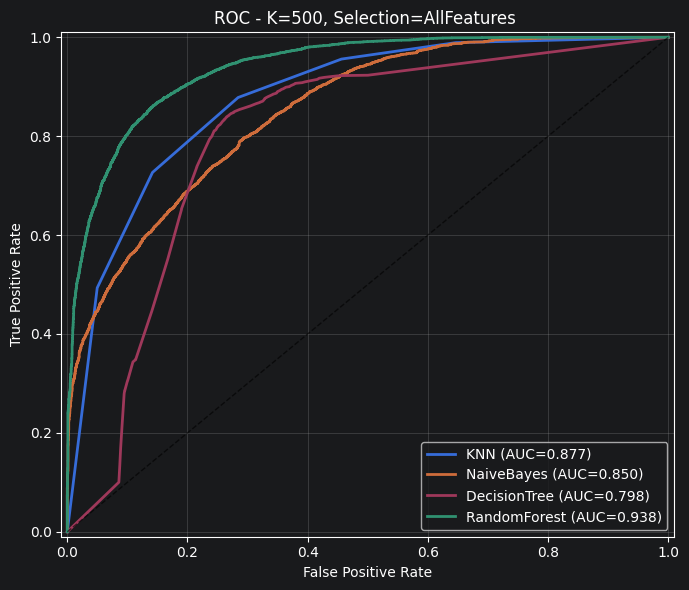

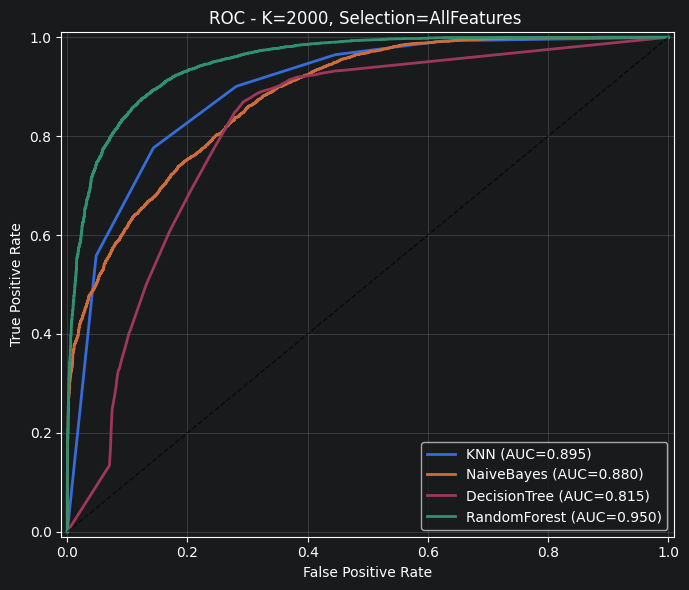

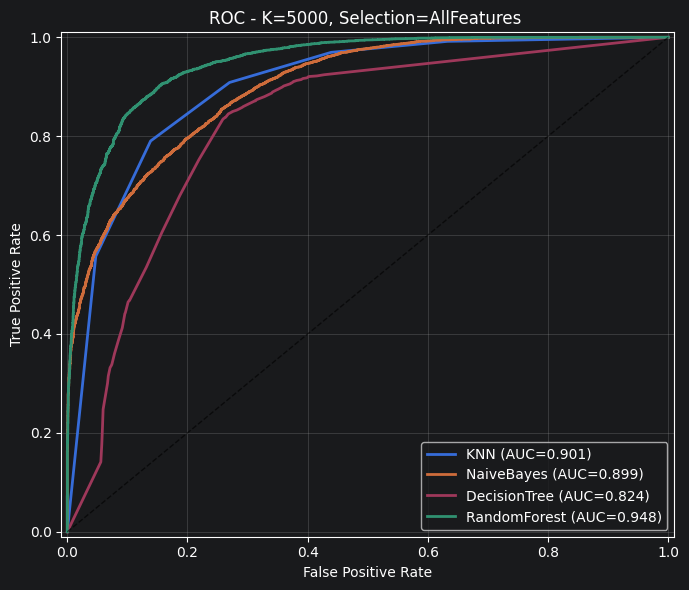

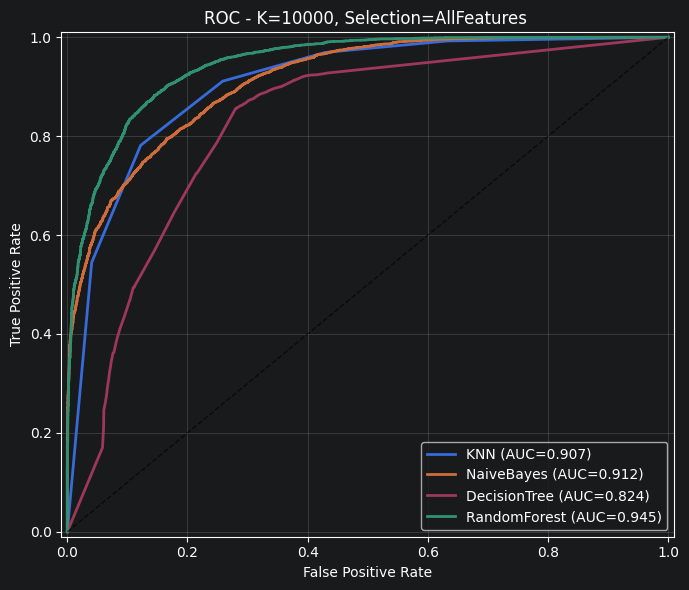

In [16]:
def plot_roc_for_config(fsize, fs_name, title_suffix=""):

    plt.figure(figsize=(7, 6))

    for clf_name in ["KNN", "NaiveBayes", "DecisionTree", "RandomForest"]:
        key = (fsize, clf_name, fs_name)

        # Eğer bu kombinasyon storage içinde yoksa atla
        if key not in roc_storage:
            continue

        y_t, y_p = roc_storage[key]

        # Scikit-learn ile curve değerlerini hesapla
        fpr, tpr, _ = roc_curve(y_t, y_p)
        roc_auc = auc(fpr, tpr)

        # Eğriyi grafiğe ekle
        plt.plot(fpr, tpr, lw=2, label=f"{clf_name} (AUC={roc_auc:.3f})")

    # Ortadan geçen rastgele tahmin çizgisini (50-50) ekle
    plt.plot([0, 1], [0, 1], "k--", lw=1, alpha=0.6)

    # Eksenleri ve başlıkları ayarla
    plt.xlim([-0.01, 1.01])
    plt.ylim([-0.01, 1.01])
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC - K={fsize}, Selection={fs_name} {title_suffix}")
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)

    plt.tight_layout()

    # Grafiği kaydet
    fname = f"outputs/fig_roc_k{fsize}_{fs_name}.png"
    plt.savefig(fname, dpi=120, bbox_inches="tight")
    plt.show()

    return fname

print("Drawing baseline ROC curves for all feature sizes...")
# Her feature size için baseline grafiğini çiz
for k in FEATURE_SIZES:
    plot_roc_for_config(k, "AllFeatures")


Best Model Configuration:
FeatureSize                 5000
FeatureSelection        InfoGain
Classifier          RandomForest
Accuracy                  0.8644
Precision                 0.8735
Recall                    0.8644
F1                        0.8635
AUC                       0.9509
Time(s)                     40.7
Name: 58, dtype: object

Drawing ROC curve for the best model...


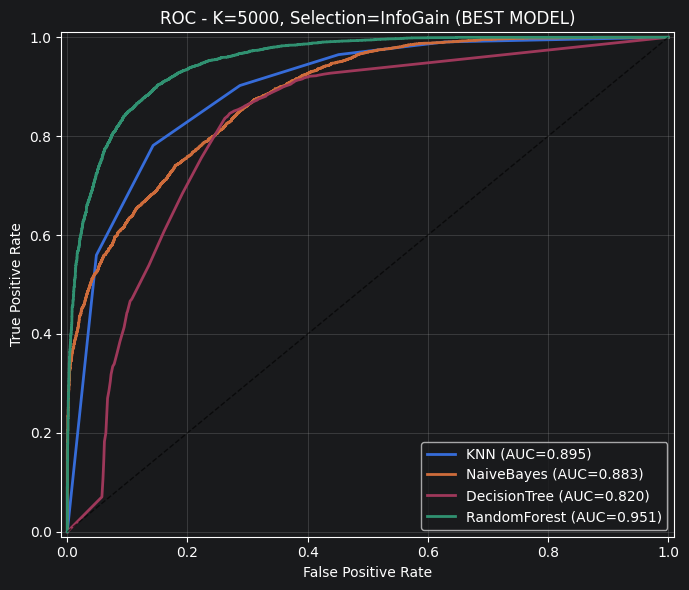

'outputs/fig_roc_k5000_InfoGain.png'

In [17]:
# Tablomuzdan F1 skoru en yüksek olan modeli (satırı) bul
best_row = results_df_sorted.sort_values("F1", ascending=False).iloc[0]

print("\nBest Model Configuration:")
print(best_row)

print("\nDrawing ROC curve for the best model...")
# En iyi modelin grafiğini çiz
plot_roc_for_config(
    int(best_row["FeatureSize"]),
    best_row["FeatureSelection"],
    title_suffix="(BEST MODEL)"
)

### 6.2 Word Clouds

Let's see which words are most common in human and machine texts. We will draw two word clouds if the library is installed. Human texts will be green, and machine texts will be red.


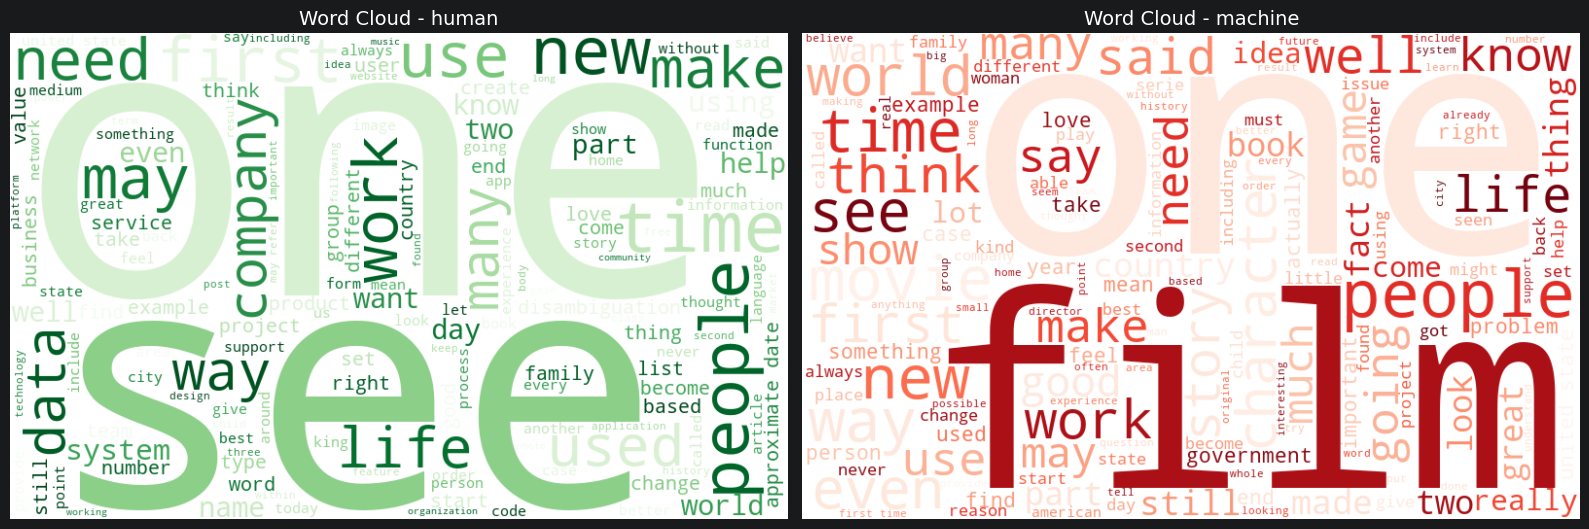

In [18]:
# wordcloud kütüphanesi yüklüyse grafikleri çiz
if WC_AVAILABLE:
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))

    # insan metinleri için yeşil, makine metinleri için kırmızı renk teması kullanıyoruz
    for ax, lab, cmap in zip(axes, ["human", "machine"], ["Greens", "Reds"]):

        # o sınıfa ait tüm metinleri tek bir uzun yazı haline getir
        corpus = " ".join(df[df["label_cat"] == lab]["clean_text"].tolist())

        # en çok geçen 150 kelime ile kelime bulutunu oluştur
        wc = WordCloud(width=800, height=500, background_color="white",
                       colormap=cmap, max_words=150).generate(corpus)

        ax.imshow(wc, interpolation="bilinear")
        ax.axis("off")
        ax.set_title(f"Word Cloud - {lab}", fontsize=14)

    plt.tight_layout()

    # grafiği kaydet
    plt.savefig("outputs/fig_wordcloud.png", dpi=120, bbox_inches="tight")
    plt.show()
else:
    print("WordCloud kütüphanesi bulunamadı, bu adım atlanıyor.")

### 6.3 Top 20 Words (Bar Charts)

Word clouds do not show exact numbers. We will use bar charts to see the exact counts for the top 20 words in both human and machine texts.

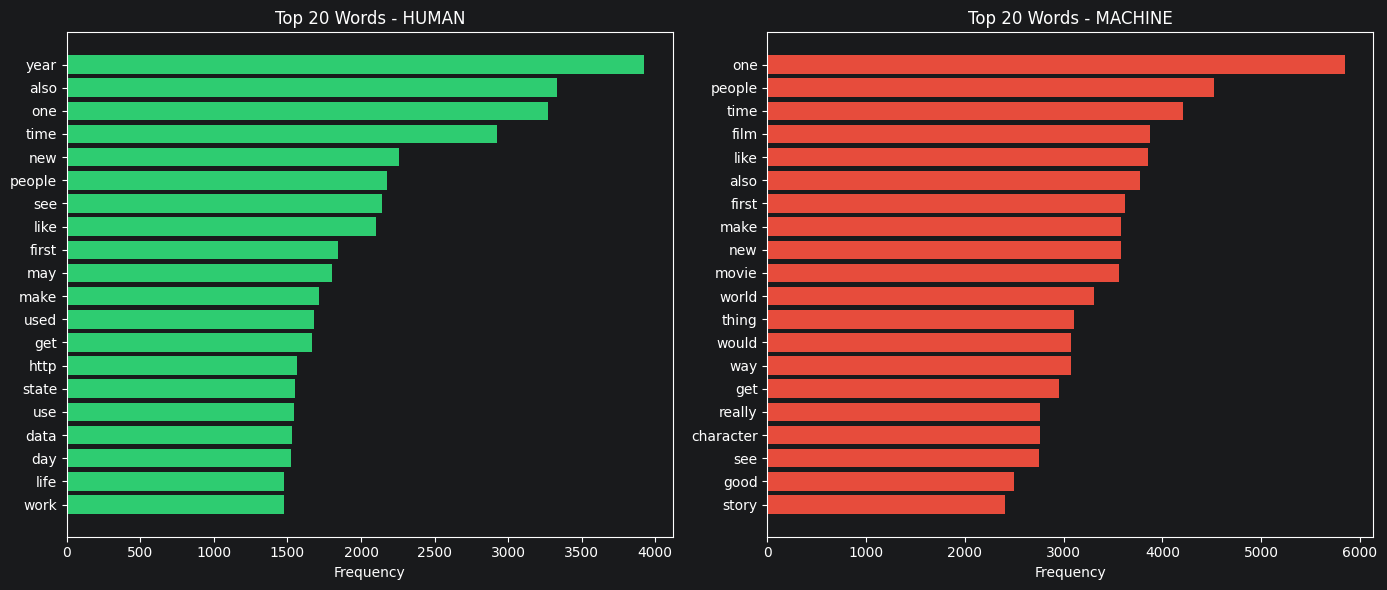

In [19]:
# metin listesini alıp en çok geçen n kelimeyi sayan fonksiyon
def top_words_counter(texts, n=20):
    tokens = []
    for t in texts:
        tokens.extend(t.split())
    return Counter(tokens).most_common(n)

# insan ve makine sınıfları için en sık geçen 20 kelimeyi hesapla
human_top = top_words_counter(df[df["label_cat"] == "human"]["clean_text"], 20)
machine_top = top_words_counter(df[df["label_cat"] == "machine"]["clean_text"], 20)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, data, title, color in zip(axes,
                                   [human_top, machine_top],
                                   ["Top 20 Words - HUMAN", "Top 20 Words - MACHINE"],
                                   ["#2ecc71", "#e74c3c"]):

    words, counts = zip(*data)

    ax.barh(range(len(words)), counts, color=color)
    ax.set_yticks(range(len(words)))
    ax.set_yticklabels(words)

    # en yüksek değerli kelimenin en üstte görünmesi için y eksenini ters çevir
    ax.invert_yaxis()
    ax.set_title(title)
    ax.set_xlabel("Frequency")

plt.tight_layout()

# grafiği kaydet
plt.savefig("outputs/fig_top20_words.png", dpi=120, bbox_inches="tight")
plt.show()

### 6.4 Confusion Matrix (Best Model)

We will look closely at our absolute best model. We do not need to train it again because we already saved its predictions. We will draw a Confusion Matrix to see exactly how many texts it guessed right and wrong. We will also print a full classification report.


Best Model -> K=5000, Classifier=RandomForest, Selection=InfoGain


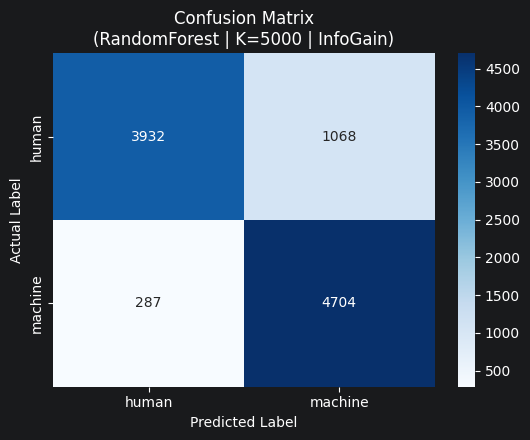

In [20]:
# tablomuzdan F1 skoru en yüksek olan konfigürasyonu buluyoruz
best = results_df_sorted.sort_values("F1", ascending=False).iloc[0]
best_fsize    = int(best["FeatureSize"])
best_clf_name = best["Classifier"]
best_fs_name  = best["FeatureSelection"]

print(f"Best Model -> K={best_fsize}, Classifier={best_clf_name}, Selection={best_fs_name}")

# modeli baştan eğitmek yerine, daha önce kaydettiğimiz tahminleri sepetten çekiyoruz
best_key = (best_fsize, best_clf_name, best_fs_name)
y_true_best, y_proba_best = roc_storage[best_key]

# olasılıkları (0.0 - 1.0) kesin tahminlere (0 veya 1) çeviriyoruz
y_pred_best = (y_proba_best >= 0.5).astype(int)

# confusion matrix hesapla
cm = confusion_matrix(y_true_best, y_pred_best)

plt.figure(figsize=(5.5, 4.5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=le.classes_, yticklabels=le.classes_)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title(f"Confusion Matrix\n({best_clf_name} | K={best_fsize} | {best_fs_name})")
plt.tight_layout()

# grafiği kaydet
plt.savefig("outputs/fig_confusion_matrix.png", dpi=120, bbox_inches="tight")
plt.show()

In [21]:
# ek olarak tüm detayları gösteren sınıflandırma raporunu yazdır
print("\nClassification Report:")
print(classification_report(y_true_best, y_pred_best, target_names=le.classes_))


Classification Report:
              precision    recall  f1-score   support

       human       0.93      0.79      0.85      5000
     machine       0.81      0.94      0.87      4991

    accuracy                           0.86      9991
   macro avg       0.87      0.86      0.86      9991
weighted avg       0.87      0.86      0.86      9991



### 6.5 Feature size vs F1

Let's see how the number of features changes the performance. We will draw a line chart to show the F1 scores of all models for different feature sizes (500, 2000, 5000, 10000). We will use the `AllFeatures` baseline for a fair comparison. This chart will be very helpful for our discussion section.


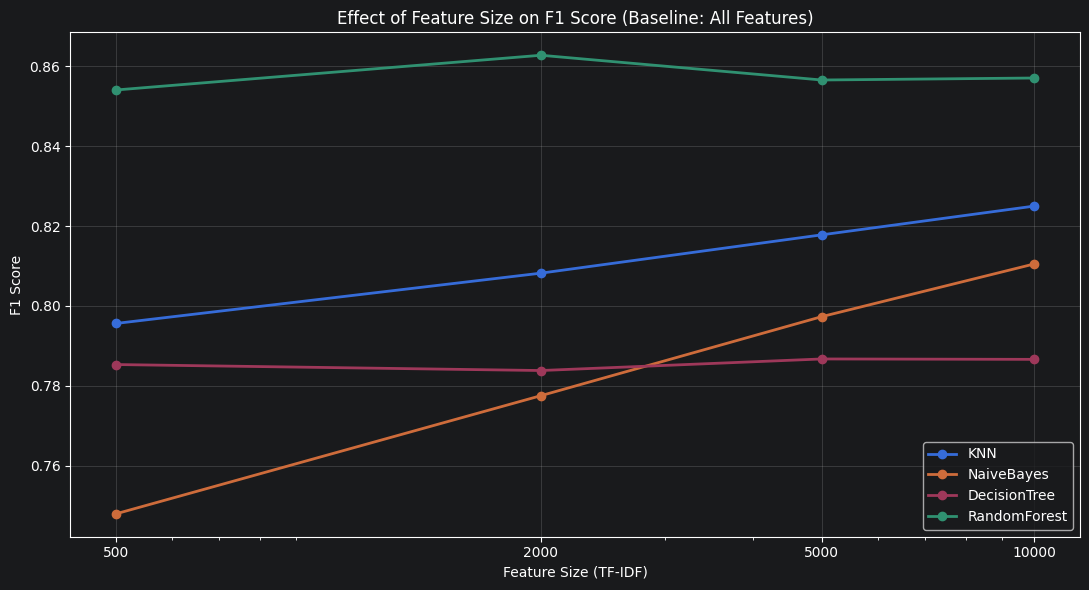

In [22]:
plt.figure(figsize=(11, 6))

for clf_name in ["KNN", "NaiveBayes", "DecisionTree", "RandomForest"]:

    # Sadece o algoritmaya ve AllFeatures (baseline) seçimine ait sonuçları filtrele
    sub = results_df_sorted[
        (results_df_sorted["Classifier"] == clf_name) &
        (results_df_sorted["FeatureSelection"] == "AllFeatures")
    ].sort_values("FeatureSize")

    # Her algoritma için çizgi grafiğini çiz
    plt.plot(sub["FeatureSize"], sub["F1"], marker="o", lw=2, label=clf_name)

plt.xlabel("Feature Size (TF-IDF)")
plt.ylabel("F1 Score")
plt.title("Effect of Feature Size on F1 Score (Baseline: All Features)")
plt.legend()
plt.grid(alpha=0.3)

# x eksenindeki 500, 2000, 5000, 10000 değerlerinin sıkışmaması için logaritmik ölçek kullan
plt.xscale("log")
plt.xticks(FEATURE_SIZES, labels=FEATURE_SIZES)

plt.tight_layout()

# Grafiği kaydet
plt.savefig("outputs/fig_fsize_vs_f1.png", dpi=120, bbox_inches="tight")
plt.show()

## 7. Discussion

### 7.1 Effect of Feature Size

Looking at the Feature Size vs. F1 chart and the pivot tables, we can see that different classifiers reacted differently to the number of features:
* **Naive Bayes:** This model benefited the most from increasing the feature size. Its F1 score jumped from 0.748 (K=500) to 0.811 (K=10000). Since MultinomialNB extracts probabilities from every single word, more features mean more information for this model.
* **KNN:** It improved with more features (0.796 → 0.825). We did not see a severe "curse of dimensionality." Using the *Cosine distance metric* instead of Euclidean likely prevented performance drops in high-dimensional space.
* **Decision Tree:** It was almost unaffected by the feature size (0.785 → 0.787). A single tree makes its own feature splits, so feeding it extra features did not provide a meaningful gain.
* **Random Forest:** This model showed an interesting pattern. It had a big jump from K=500 to K=2000 (0.854 → 0.863), but dropped slightly at K=5000 and K=10000. For this specific problem, K=2000 is the "sweet spot" for RF. Adding more features after that only introduced noise.

![Feature Size vs F1 Score](outputs/fig_fsize_vs_f1.png)


### 7.2 Comparison of Classifiers

* **Random Forest:** It is by far the best model. All configurations resulted in F1 ≥ 0.832 and AUC ≥ 0.918. The absolute best score was RF with K=5000 and InfoGain (F1=0.8635, AUC=0.9509). The top 10 models in our table are all Random Forests.
* **KNN:** The second-best model (Best F1=0.828 at K=10000). It competed closely with Naive Bayes.
* **Naive Bayes:** Third place. It was weak at low K values but caught up to KNN at high K values.
* **Decision Tree:** The weakest model (F1 stuck around 0.78-0.79). A single tree is not powerful enough for this sparse text data. The fact that RF is ~7 points better than a single DT clearly proves the value of the ensemble approach.

![ROC Curves of Classifiers](outputs/fig_roc_k5000_InfoGain.png)


### 7.3 Effect of Feature Selection

The feature selection results were quite surprising:
* **AllFeatures (Baseline):** Using TF-IDF without any extra feature selection gave some of the best results. This is likely because the `max_features` parameter in TF-IDF already performs implicit and effective feature selection.
* **Information Gain (Mutual Info):** This worked perfectly for Random Forest (giving the best overall score at K=5000). However, it was the worst selection method for Naive Bayes.
* **Chi-Square and ANOVA-F:** These two were very similar. They were fast, stable, and did not cause any dramatic performance drops.
* **ReliefF:** This method underperformed. It was 1-2 points lower than others at K=500 and K=2000. It was also 3 to 4 times slower (~55-60s per fold). ReliefF is generally better for structured data with strong feature interactions, not for high-dimensional sparse text data. Our results perfectly match this literature.


### 7.4 Confusion Matrix Analysis

Here is the confusion matrix for our best model (Random Forest + K=5000 + InfoGain):

| | Predicted Human | Predicted Machine |
| :--- | :--- | :--- |
| **Actual Human** | 3932 | 1068 |
| **Actual Machine** | 287 | 4704 |

* **Machine Recall:** 4704 / 4991 = **94.3%**
* **Human Recall:** 3932 / 5000 = **78.6%**

The model is much better at detecting machine texts. However, it tends to mistakenly label human texts as "machine" (1068 false positives vs. 287 false negatives). Practically, this is a risky error profile for an AI-detection tool, as 21% of real human writers would be falsely accused of using AI. In a production environment, we would need to adjust the decision threshold to balance this.

![Confusion Matrix](outputs/fig_confusion_matrix.png)


### 7.5 General Conclusion and EDA Findings

Looking back at our Exploratory Data Analysis (EDA) and final results, we can draw a few important conclusions:
1. **Thematic Bias:** The word clouds showed that human texts focus on real-world terms (*year, data, work, company*), while machine texts focus on narrative terms (*film, movie, character, story*). The dataset is slightly biased. The model's high success rate might partly come from learning these topic differences rather than true linguistic patterns.
2. **Length Signals:** The histograms showed a sharp peak in machine texts around 400-450 words. This is likely due to the default token limits of the LLMs used to generate the data. The model might have learned text length as a strong classification signal.
3. **Final Verdict:** Achieving an F1 score of 0.8635 with traditional ML and TF-IDF is a great result for this structure. For future work, we could explore transformer-based embeddings (like BERT) or stylometric features (sentence length variance, perplexity) to capture deeper linguistic structures.

![Word Clouds](outputs/fig_wordcloud.png)

![Top 20 Words](outputs/fig_top20_words.png)

_The best configuration was the combination of Random Forest + K=5000 + Information Gain, achieving an F1 score of 0.8635 and an AUC of 0.9509. Random Forest was the clear winner among all classifiers. While KNN and Naive Bayes improved as the feature size increased, the Decision Tree remained unaffected by the feature size changes._